# Direct Standardization: The Idea and the Standard Population

*Demographic Analysis Series · Module 1 (Mortality) · Lesson 1.2a*  
*Author: Jiajia Li | Published: September 12, 2026 | Reading time: about 20 minutes*

[Lesson 1.1c](/blog/demographic-m1l1c-mortality-indicators) taught us to read mortality one age group at a time. Now we return to a practical question: if we want a single number for each population, how can we avoid mistaking “more older people” for “higher mortality at a given age”?

**Direct standardization keeps each population's age-specific rates and replaces its age composition with a common set of weights.**

We will derive that operation, compare the Segi and WHO world standards, and use Python to see why the choice of weights changes standardized rates—and sometimes their ranking. Populations A and B below are constructed teaching examples. The standard-population weights come from the original WHO report.

**What you'll learn**

- How the weighted-average identity for crude rates leads to direct standardization
- What the standard population supplies, and how to keep rate units consistent
- How Segi and WHO weights differ, including age-group alignment and rounding
- When a ranking can change with the standard, and when it cannot

**Reading anchors:** Carmichael (2016), Ch. 2, pp. 49–56; Wachter (2014), §6.5. These are the reading locations specified in the course syllabus; the numerical standards used here are checked against WHO Table 1. The examples are original teaching constructions. Lesson 1.2b will develop the full two-country application.

## 1. A Crude Rate Is a Weighted Average

For a common observation period, divide each population into non-overlapping age groups $x$ that cover the full age range under study. Let:

| Symbol | Meaning | Unit |
|:--|:--|:--|
| $D_{gx}$ | Deaths in population $g$, age group $x$ | Deaths |
| $E_{gx}$ | Corresponding exposure to the risk of death | Person-years |
| $m_{gx}=D_{gx}/E_{gx}$ | Age-specific death rate | Per person-year |
| $p_{gx}=E_{gx}/\sum_x E_{gx}$ | Age group's share of total exposure | Dimensionless |

The denominator of a rate is exposure time. For a one-year period, the mid-year population is often used to approximate person-years. For a period lasting $T$ years, the approximation becomes $E_{gx}\approx T\bar P_{gx}$. Dividing several years of deaths by a single year's mid-year population does not, by itself, produce an annual rate.

Sum deaths across ages and divide by total exposure:

$$
\begin{aligned}
M_g
&=\frac{\sum_x D_{gx}}{\sum_x E_{gx}}\\
&=\frac{\sum_x m_{gx}E_{gx}}{\sum_x E_{gx}}\\
&=\sum_x p_{gx}m_{gx}.
\end{aligned}
$$

The identity reveals two ingredients: a **mortality schedule**, $m_{gx}$, and a **composition**, $p_{gx}$. A difference between crude rates may reflect either ingredient, or both.

To make the arithmetic visible, our first example has just two groups: younger and older. Rates are expressed per 1,000 person-years. These broad groups are a teaching device; applied standardization generally needs finer ages.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# All rate examples in this notebook are deliberately constructed for teaching.
# Standard-population weights in Section 3 are the only externally sourced data.
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial'],
    'font.size': 11,
    'figure.dpi': 125,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.8,
    'legend.frameon': False,
    'svg.fonttype': 'none',
    'pdf.fonttype': 42,
})
GREEN, RUST = '#35634e', '#a95b3d'
ages = pd.Index(['Younger', 'Older'], name='Age group')
rates = pd.DataFrame({'A': [1.0, 20.0], 'B': [0.8, 16.0]}, index=ages)
composition = pd.DataFrame({'A': [0.9, 0.1], 'B': [0.6, 0.4]}, index=ages)
assert np.allclose(composition.sum(), 1)
crude = (rates * composition).sum()
example = pd.DataFrame({
    'A rate / 1,000 PY': rates['A'],
    'B rate / 1,000 PY': rates['B'],
    'A exposure share': composition['A'],
    'B exposure share': composition['B'],
})
display(example.round(3))
print(f"Crude rate A = {crude['A']:.2f}; B = {crude['B']:.2f} per 1,000 person-years")
assert np.allclose(crude.to_numpy(), [2.90, 6.88])

,"A rate / 1,000 PY","B rate / 1,000 PY",A exposure share,B exposure share
Age group,,,,
Younger,1.0,0.8,0.9,0.6
Older,20.0,16.0,0.1,0.4


Crude rate A = 2.90; B = 6.88 per 1,000 person-years


Population A's crude rate is $0.9\times1+0.1\times20=2.90$; B's is $0.6\times0.8+0.4\times16=6.88$, both per 1,000 person-years.

The crude comparison puts B above A, even though **B has lower mortality in both age groups**. Older people account for 40% of B's exposure but only 10% of A's. The crude rates correctly describe mortality frequency in the populations as observed. They do not isolate the comparison at a common age composition.

## 2. Direct Standardization: Common Weights, Separate Schedules

Choose a standard population with $N_x^S$ people in age group $x$. Convert its counts into weights:

$$w_x^S=\frac{N_x^S}{\sum_x N_x^S},\qquad w_x^S\ge0,\quad\sum_xw_x^S=1.$$

Apply those weights to population $g$'s own age-specific rates:

$$\boxed{M_g^S=\sum_xw_x^S m_{gx}.}$$

We can also derive the formula using hypothetical deaths. Assign the standard population a common observation duration $T$, giving exposure $E_x^S=TN_x^S$. Applying the rates $m_{gx}$ produces hypothetical deaths $D_{gx}^S=m_{gx}E_x^S$. Then:

$$M_g^S=\frac{\sum_xD_{gx}^S}{\sum_xE_x^S}
=\frac{\sum_xm_{gx}TN_x^S}{T\sum_xN_x^S}
=\sum_xw_x^Sm_{gx}.$$

These hypothetical counts define a summary measure. They are not a forecast of actual deaths or a claim about what would happen if a population's age structure were changed by an intervention.

**Weighting does not change the unit.** If the input rates are per person-year, multiply the final result by 1,000 to report it per 1,000 person-years. If the inputs are already per 1,000 person-years, the weighted average has that unit: do not multiply again. Nor should you multiply by age-interval width $n$; the population weights already represent the shares of the age groups.

Let both populations now use a standard that is 80% younger and 20% older.

,Crude,Standardized
A,2.90,4.80
B,6.88,3.84


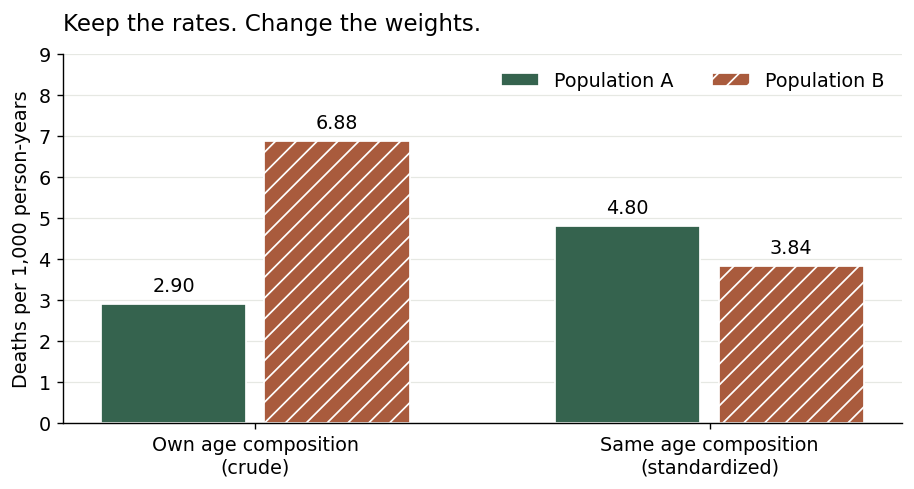

In [2]:
standard = pd.Series([0.8, 0.2], index=ages, name='Common weight')
assert standard.index.equals(rates.index)
assert np.isclose(standard.sum(), 1)
standardized = rates.mul(standard, axis='index').sum()
summary = pd.DataFrame({'Crude': crude, 'Standardized': standardized})
display(summary.round(2))
assert np.allclose(standardized.to_numpy(), [4.80, 3.84])

# Conclusion: changing only the weights reverses the misleading crude comparison.
fig, ax = plt.subplots(figsize=(7.2, 3.8), layout='constrained')
x = np.arange(2)
for offset, group, color, hatch in [(-0.18, 'A', GREEN, ''), (0.18, 'B', RUST, '//')]:
    values = summary.loc[group].to_numpy()
    bars = ax.bar(x + offset, values, width=0.32, label=f'Population {group}',
                  color=color, hatch=hatch, edgecolor='white')
    ax.bar_label(bars, fmt='%.2f', padding=5, fontsize=11)
ax.set_xticks(x, ['Own age composition\n(crude)', 'Same age composition\n(standardized)'])
ax.set_ylabel('Deaths per 1,000 person-years')
ax.set_ylim(0, 9)
ax.legend(loc='upper right', ncol=2)
ax.set_title('Keep the rates. Change the weights.', loc='left', pad=14)
ax.set_axisbelow(True)
ax.grid(axis='y', color='#e6e8e3', linewidth=0.7)
plt.show()

**Figure 1 | Common weights change the question answered by the comparison.** The left pair uses each population's own exposure composition; the right pair uses the same 80% / 20% weights. B's standardized rate is 3.84, below A's 4.80, per 1,000 person-years. All values come from the constructed example above; no confidence intervals are estimated.

Keep three objects separate:

- The **crude rate** summarizes mortality in the observed population with its own age composition.
- The **standardized rate** summarizes the age-specific schedule under specified common weights.
- The **standard population** supplies those weights. It does not supply the populations' mortality schedules. Replacing their rates with a common schedule would be a different operation.

## 3. Segi and WHO: Two Different World Standards

A standard can be a real population or a prescribed synthetic distribution. Its total size is immaterial: writing the counts for 100, 100,000, or 1,000,000 people leaves the normalized weights unchanged.

The Segi world standard is widely used in international cancer statistics. The WHO World Standard proposed in 2001 was constructed from the estimated and projected average world age structure for **2000–2025**, rather than an observed population in 2001. The word *world* does not make the two standards interchangeable. See the [WHO report](https://cdn.who.int/media/docs/default-source/gho-documents/global-health-estimates/gpe_discussion_paper_series_paper31_2001_age_standardization_rates.pdf) and [IARC's age-standardization chapter](https://publications.iarc.who.int/_publications/media/download/3646/87bdabc699a62310ca65e74059a3a7053602c6cd.pdf).

The next cell transcribes the two percentage columns from WHO Table 1. That comparison table combines the WHO groups 85–89, 90–94, 95–99, and 100+ into **85+**. We use its 18-group representation throughout this comparison.

In [3]:
# Source: Ahmad et al. (WHO, 2001), Table 1, printed p. 10.
# Percentages are transcribed as printed, including the rounded WHO 85+ aggregate.
age_groups = [f'{x}-{x+4}' for x in range(0, 85, 5)] + ['85+']
standards_pct = pd.DataFrame({
    'Segi': [12, 10, 9, 9, 8, 8, 6, 6, 6, 6, 5, 4, 4, 3, 2, 1, 0.5, 0.5],
    'WHO': [8.86, 8.69, 8.60, 8.47, 8.22, 7.93, 7.61, 7.15, 6.59,
            6.04, 5.37, 4.55, 3.72, 2.96, 2.21, 1.52, 0.91, 0.63],
}, index=pd.Index(age_groups, name='Age group'))
assert standards_pct.shape == (18, 2)
assert np.all(standards_pct.to_numpy() >= 0)
assert np.allclose(standards_pct.sum().to_numpy(), [100, 100.03])

# Normalize the PRINTED values; retain the original percentages above for auditing.
weights = standards_pct.div(standards_pct.sum(), axis='columns')
assert np.allclose(weights.sum(), 1)
display(standards_pct.style.format('{:.2f}'))
print('Printed totals (%):', standards_pct.sum().round(2).to_dict())
print('Normalized totals:', weights.sum().round(12).to_dict())
print('Share aged 70+ (%):', (weights.loc['70-74':].sum() * 100).round(3).to_dict())

,Segi,WHO
Age group,,
0-4,12.00,8.86
5-9,10.00,8.69
10-14,9.00,8.60
15-19,9.00,8.47
20-24,8.00,8.22
25-29,8.00,7.93
30-34,6.00,7.61
35-39,6.00,7.15
40-44,6.00,6.59


Printed totals (%): {'Segi': 100.0, 'WHO': 100.03}
Normalized totals: {'Segi': 1.0, 'WHO': 1.0}
Share aged 70+ (%): {'Segi': 4.0, 'WHO': 5.268}


**Why not simply divide by 100?** Although Table 1 prints a total of 100%, its rounded WHO entries add to **100.03%**. We normalize by the actual column sum and retain the transcribed percentages for inspection. Reproducing an official estimate requires that estimate's specified weights, precision, and age groups; this rounded teaching implementation may differ in the last decimal places.

The following figure compares normalized age weights. It contains no mortality observations.

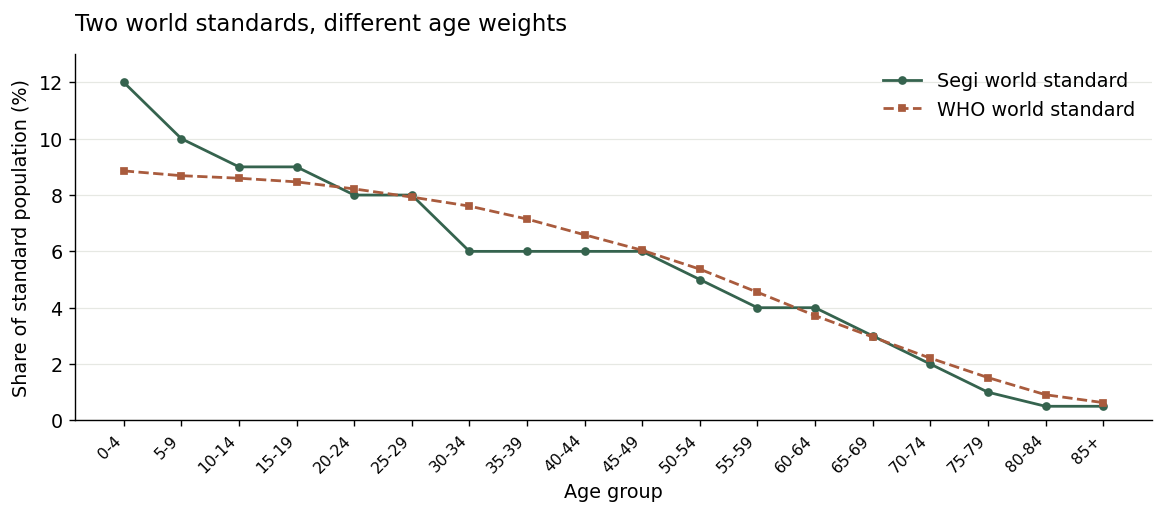

In [4]:
# Conclusion: choosing a standard changes the ages receiving greater emphasis.
fig, ax = plt.subplots(figsize=(9.2, 4.0), layout='constrained')
x = np.arange(len(weights))
ax.plot(x, weights['Segi'] * 100, color=GREEN, marker='o', markersize=4,
        linewidth=1.6, label='Segi world standard')
ax.plot(x, weights['WHO'] * 100, color=RUST, marker='s', markersize=4,
        linestyle='--', linewidth=1.6, label='WHO world standard')
ax.set_xticks(x, weights.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Share of standard population (%)')
ax.set_xlabel('Age group')
ax.set_ylim(0, 13)
ax.legend(loc='upper right')
ax.set_title('Two world standards, different age weights', loc='left', pad=14)
ax.set_axisbelow(True)
ax.grid(axis='y', color='#e6e8e3', linewidth=0.7)
plt.show()

**Figure 2 | Age weights in the Segi and WHO world standards.** Solid circles denote Segi; dashed squares denote WHO. Values are normalized from WHO (2001), Table 1, with 85+ aggregated. Marker and line styles distinguish the standards in grayscale. These are prescribed distributions, not sample estimates, so there are no error bars.

Relative to Segi, the WHO distribution gives less weight to children and more to ages 70 and above. That does not mean every adult group receives more weight: the entries for 60–64 and 65–69 illustrate why the whole distribution matters.

### Align the Age Groups Before Weighting

Suppose the mortality data separate **age 0** and **ages 1–4**, but the standard provides **ages 0–4**. Pool the death counts and exposure first:

$$m_{0-4}=\frac{D_0+D_{1-4}}{E_0+E_{1-4}}.$$

The arithmetic mean of the two rates is generally wrong. Splitting the standard's 0–4 weight in a 1:4 ratio based only on interval widths is also unjustified. If you have rates but no corresponding exposure, you cannot recover the pooled rate exactly.

Open-ended groups must align too: 85+ should be matched to 85+. Different compositions within a wide open-ended group can leave residual age differences; finer groups help when the data support them. A missing age-specific rate is not zero. If the study deliberately restricts the age range, state that restriction and renormalize the standard over the included ages.

## 4. Why Does the Choice of Standard Matter?

### 4.1 A Population's Standardized Rate Can Change

Hold the mortality schedule fixed and apply two standards, $S$ and $T$:

$$M_g^S-M_g^T=\sum_x(w_x^S-w_x^T)m_{gx}.$$

Moving weight from lower-rate ages to higher-rate ages raises the average. Nothing has happened to anyone's age-specific mortality; the summary now places greater emphasis on different parts of the schedule.

### 4.2 When Can Two Populations Switch Rank?

Under a common standard $S$, the standardized rate difference is:

$$M_A^S-M_B^S=\sum_x w_x^S(m_{Ax}-m_{Bx}).$$

If $m_{Ax}\le m_{Bx}$ at every age, every set of common nonnegative weights preserves $M_A^S\le M_B^S$. The inequality is strict if at least one positively weighted age group has a strict rate difference. **A consistent age-specific ordering cannot reverse merely because the standard changes.**

If A is higher at some ages and B is higher at others, the age-specific differences have opposite signs. Reweighting can then change the sign of their sum. **Crossing schedules permit a reversal; they do not guarantee that any particular pair of standards will produce one.**

To isolate that mechanism, start a *new* teaching example. A's younger/older rates are 1 and 20; B's are 3 and 10, all per 1,000 person-years. These replace—not extend—the first example. If $q$ is the older group's share in the standard, then:

$$M_A(q)=1+19q,\qquad M_B(q)=3+7q,$$

$$M_A(q)-M_B(q)=-2+12q.$$

The lines cross at $q=1/6\approx16.67\%$. Below that share A has the lower standardized rate; above it B does.

,Older share,"A / 1,000 PY","B / 1,000 PY"
0,0.1000,2.9000,3.7000
1,0.1667,4.1667,4.1667
2,0.3000,6.7000,5.1000


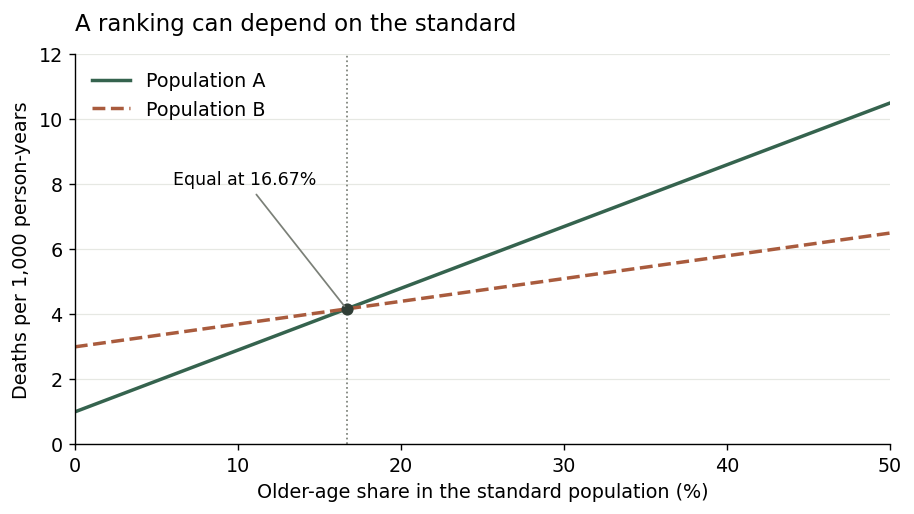

In [5]:
# Separate teaching example: crossing age-specific rates, not real country data.
q = np.linspace(0, 0.5, 101)
rate_a = 1 + 19 * q
rate_b = 3 + 7 * q
crossing = 1 / 6
scenarios = pd.DataFrame({'Older share': [0.10, crossing, 0.30]})
scenarios['A / 1,000 PY'] = 1 + 19 * scenarios['Older share']
scenarios['B / 1,000 PY'] = 3 + 7 * scenarios['Older share']
display(scenarios.round(4))
assert np.isclose(1 + 19 * crossing, 3 + 7 * crossing)
assert 1 + 19 * 0.1 < 3 + 7 * 0.1
assert 1 + 19 * 0.3 > 3 + 7 * 0.3

fig, ax = plt.subplots(figsize=(7.2, 4.0), layout='constrained')
ax.plot(q * 100, rate_a, color=GREEN, linewidth=2, label='Population A')
ax.plot(q * 100, rate_b, color=RUST, linestyle='--', linewidth=2, label='Population B')
ax.axvline(crossing * 100, color='#7b8078', linewidth=1, linestyle=':')
ax.scatter([crossing * 100], [1 + 19 * crossing], color='#303e36', zorder=3)
ax.annotate('Equal at 16.67%', xy=(crossing * 100, 1 + 19 * crossing),
            xytext=(6, 8), arrowprops={'arrowstyle': '-', 'color': '#7b8078'}, fontsize=10)
ax.set_xlabel('Older-age share in the standard population (%)')
ax.set_ylabel('Deaths per 1,000 person-years')
ax.set_xlim(0, 50)
ax.set_ylim(0, 12)
ax.legend(loc='upper left')
ax.set_title('A ranking can depend on the standard', loc='left', pad=14)
ax.set_axisbelow(True)
ax.grid(axis='y', color='#e6e8e3', linewidth=0.7)
plt.show()

**Figure 3 | Crossing age-specific rates allow a weight-dependent ranking.** The lines are calculated from the deterministic formulas above, with no sampling uncertainty. The plot shows older-age shares from 0% to 50%. At 10%, A and B have rates of 2.9 and 3.7; at 30%, they have rates of 6.7 and 5.1, per 1,000 person-years.

The 10% and 30% shares are deliberately constructed scenarios, **not the Segi and WHO standards**. This example demonstrates a mechanism. It does not establish a reversal for any particular pair of countries. Lesson 1.2b will make sensitivity to the standard part of the applied comparison.

## 5. Choosing and Reporting a Standard

Decide what comparison you want to make before calculating results. The standard should follow that purpose, rather than whichever choice produces the preferred ranking.

| Purpose | Practical choice and reporting requirement |
|:--|:--|
| Reproduce a published estimate | Match its standard version, age groups, age range, and rate unit |
| Compare with a cancer registry report | Check whether it uses Segi and which implementation; “world standard” alone is insufficient |
| Compare with a WHO indicator | Read that indicator's metadata and use its specified standard and age range |
| Compare a time series | Keep the standard fixed across years; recalculate the comparison series if the standard changes |
| Make an internal comparison | A fixed reference-year or pooled population can serve as the standard; document the weights and rationale |

A standardized rate is a **descriptive summary conditional on the chosen standard**. Age standardization controls the composition represented by the specified age groups. It does not automatically address differences in sex, socioeconomic circumstances, registration quality, or other factors, and it is not by itself a causal analysis. Death counts, population size, and crude rates remain relevant when the question concerns the absolute burden of mortality.

A reporting statement for this notebook would read:

> We directly age-standardized mortality rates to the WHO World Standard Population (Ahmad et al., 2001), using 18 age groups from 0–4 through 80–84 and 85+. We normalized the printed percentages in Table 1 by their column sum and reported rates per 1,000 person-years. We also used the Segi world standard to assess sensitivity to the choice of weights.

This statement describes the **rounded-weight implementation used here**. In an applied paper, specify the actual version, age range, weight precision, and units you used.

## 6. Check Your Understanding

1. If every standard-population count is multiplied by ten, does the standardized rate change?
2. Suppose A's rate is exactly 0.8 times B's at every age. What is their standardized rate ratio under either standard?
3. Set the older-age share in Figure 3 to 20%. What are the two standardized rates, and which is lower?

**Answers.** (1) No: normalization gives the same weights. (2) The ratio is 0.8 under either standard, because $m_{Ax}=c m_{Bx}$ implies $M_A^S=cM_B^S$. (3) A is 4.8 and B is 4.4 per 1,000 person-years; B is lower.

## Coming Next: The Two-Country Application

Lesson 1.2b will bring in age-specific deaths and exposure for two countries, align their age groups, implement `standardize_direct()`, and compare results under alternative standards. The principle to carry forward is simple: common weights hold age composition constant in a summary comparison, but the weights remain part of the specification.

[Back to the Demographic Analysis Series](/blog/series/demographic) · [Review Lesson 1.1c](/blog/demographic-m1l1c-mortality-indicators)

## References and Data Sources

1. Ahmad, O. B., Boschi-Pinto, C., Lopez, A. D., Murray, C. J. L., Lozano, R., & Inoue, M. (2001). *Age Standardization of Rates: A New WHO Standard*. GPE Discussion Paper Series No. 31. World Health Organization. Standard weights: Table 1 (printed p. 10); construction: pp. 5–6. [Original WHO PDF](https://cdn.who.int/media/docs/default-source/gho-documents/global-health-estimates/gpe_discussion_paper_series_paper31_2001_age_standardization_rates.pdf).
2. IARC. *Chapter 8. Age-standardization*. Guidance on standard populations and age-standardized rates. [Official IARC PDF](https://publications.iarc.who.int/_publications/media/download/3646/87bdabc699a62310ca65e74059a3a7053602c6cd.pdf).
3. Carmichael, G. A. (2016). *Fundamentals of Demographic Analysis: Concepts, Measures and Methods*. Ch. 2, *Comparison: Standardization and Decomposition*, pp. 49–84. The course assigns pp. 49–56 for this lesson. [Springer book and chapter listing](https://link.springer.com/book/10.1007/978-3-319-23255-3).
4. Wachter, K. W. (2014). *Essential Demographic Methods*. Harvard University Press. The course syllabus assigns §6.5 for age standardization; match the section heading to the edition you use. [Publisher's book page](https://www.hup.harvard.edu/books/9780674045576).

**Reproducibility.** All teaching data and standard weights are embedded in the code, so execution requires no external data downloads. Dependencies are NumPy, pandas, Matplotlib, and Jupyter/IPython. Figures 1 and 3 use deterministic synthetic examples; Figure 2 compares published standard weights. Assertions check weight sums, hand-calculated rates, and the ranking crossover.